In [80]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time
from george import kernels
from george.modeling import Model
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction
from multiprocessing import Pool
import os

# %matplotlib widget
# plt.close('all')

### Caricamento dei dati

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


### Pulizia dei dati dai nan

In [3]:
# Pulizia dei dati dai valori nan
t_temp = data_air['time_centered']
u_temp = data_air['Annual_Anomaly_Unc']
y_temp = data_air['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_masked = {k: v[mask] for k, v in data_air.items()}

t_temp = data_water['time_centered']
u_temp = data_water['Annual_Anomaly_Unc']
y_temp = data_water['Annual_Anomaly']

 
data_water_masked = {k: v[mask] for k, v in data_water.items()}

### Processi Gaussiani senza trend - Aria

In [81]:
def log_likelihood_air(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric=metric)
    gp = george.GP(kernel)
    gp.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])
    loglike = gp.log_likelihood(data_air_masked['Annual_Anomaly'])

    return loglike

def log_likelihood_water(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric=metric)
    gp = george.GP(kernel)
    gp.compute(data_water_masked['time_centered'], data_water_masked['Annual_Anomaly_Unc'])
    loglike = gp.log_likelihood(data_water_masked['Annual_Anomaly'])

    return loglike

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 10.0

    return params

param_names_GP = ['metric']
sampler_GP_air = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood_air, transform=log_prior)
results_GP_air = sampler_GP_air.run(min_num_live_points=300)
sampler_GP_air.print_results()

[ultranest] Sampling 300 live points from prior ...


KeyboardInterrupt: 

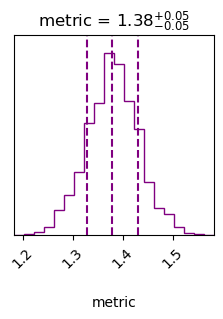

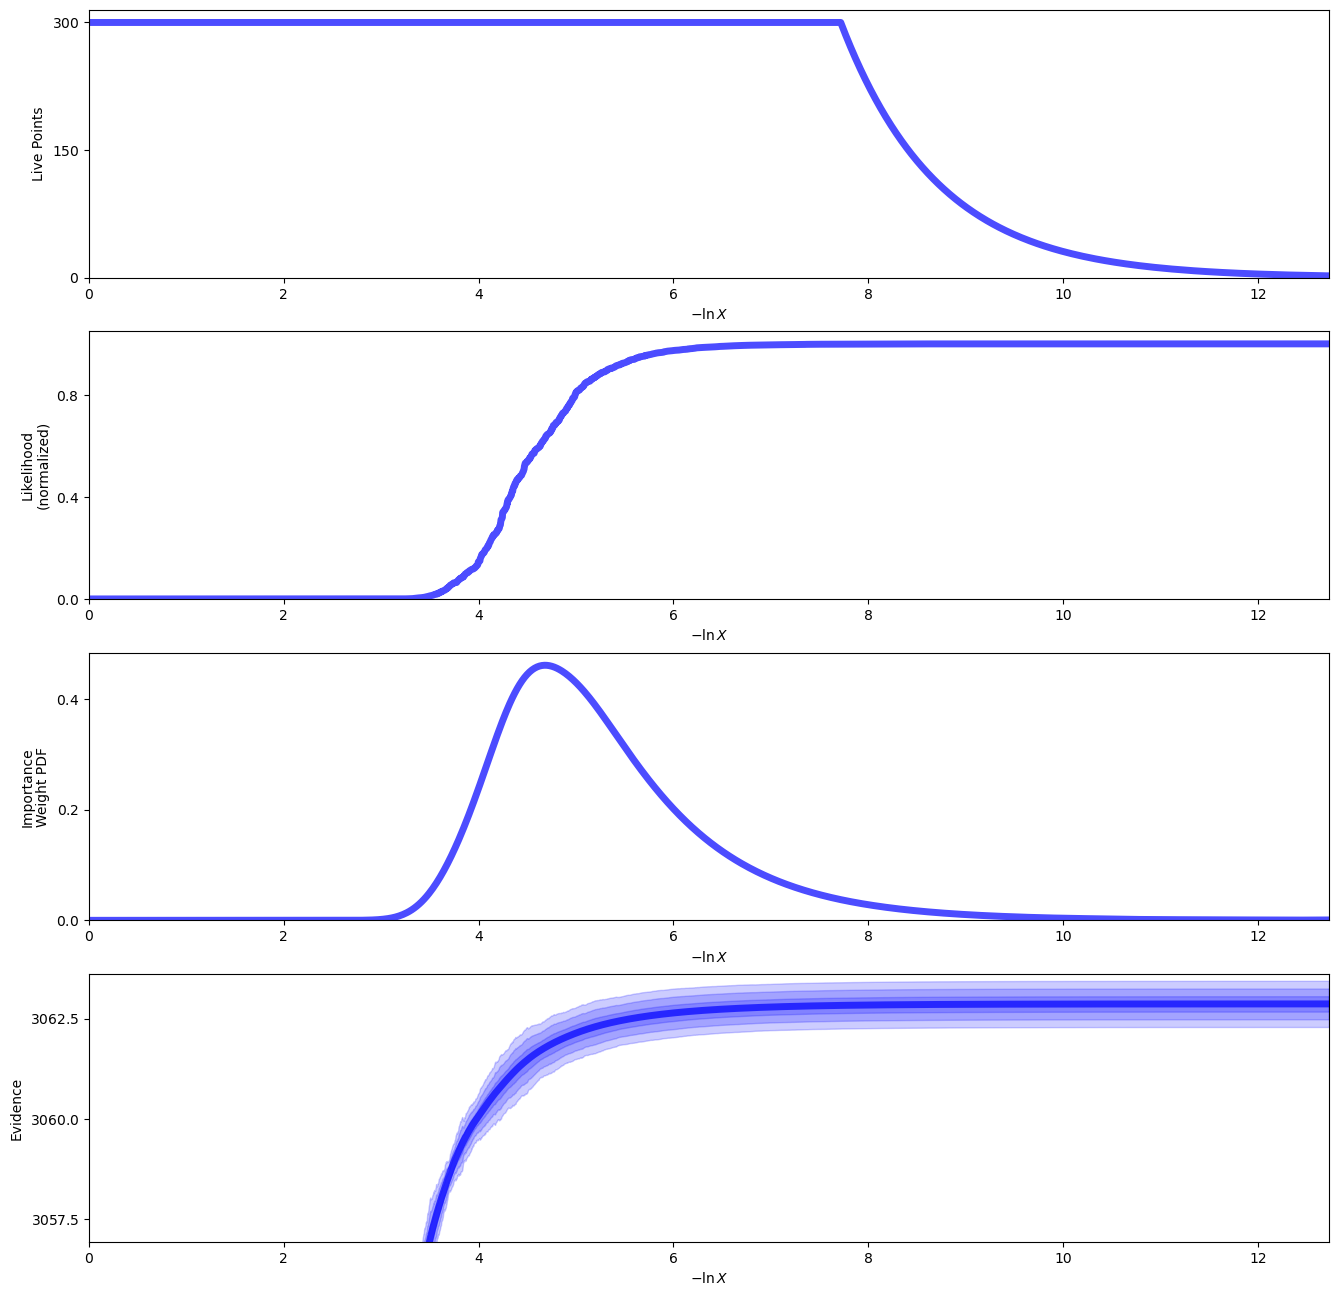

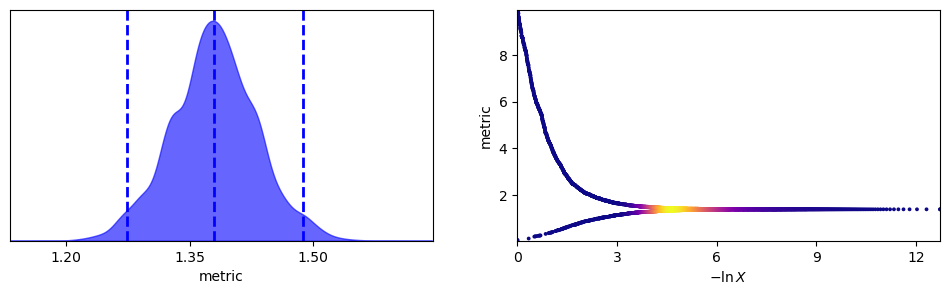

In [5]:
sampler_GP_air.plot()

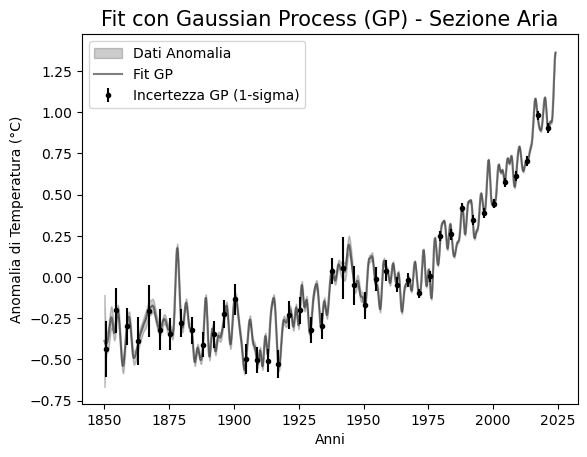

In [6]:
t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088) # Per il grafico (asse X)
t_grid_calc = t_grid_plot - t_start

mean_metric_air = results_GP_air['samples'].mean()
time_train = data_air_masked['time_centered']
anomalies_air = data_air_masked['Annual_Anomaly']
anomalies_unc_air = data_air_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric_air)
res_gp = george.GP(res_kernel)
res_gp.compute(time_train, anomalies_unc_air)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies_air, t_grid_calc, return_var=True)

plt.errorbar(data_air_masked['time_years'][::50], anomalies_air[::50], yerr=anomalies_unc_air[::50], fmt=".k", capsize=0, zorder=0)
plt.fill_between(t_grid_plot, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(t_grid_plot, pred_anomalies, "k", lw=1.5, alpha=0.5)
plt.legend(['Dati Anomalia', 'Fit GP', 'Incertezza GP (1-sigma)'])
plt.xlabel('Anni')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Fit con Gaussian Process (GP) - Sezione Aria', fontsize=15)
plt.show()


### Processi Gaussiani senza trend - Acqua

In [7]:
sampler_GP_water = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood_water, transform=log_prior)
results_GP_water = sampler_GP_water.run(min_num_live_points=300)
sampler_GP_water.print_results()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=3e+03  3.40 [3133.4001..3133.4001]*| it/evals=2391/2803 eff=95.5254% N=300 
[ultranest] Likelihood function evaluations: 2804
[ultranest]   logZ = 3129 +- 0.065
[ultranest] Effective samples strategy satisfied (ESS = 950.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.07, need <0.5)
[ultranest]   logZ error budget: single: 0.11 bs:0.06 tail:0.03 total:0.07 required:<0.50
[ultranest] done iterating.

logZ = 3128.996 +- 0.156
  single instance: logZ = 3128.996 +- 0.114
  bootstrapped   : logZ = 3129.014 +- 0.154
  tail           : logZ = +- 0.028
insert order U test : converged: True correlation: inf iterations

    metric              : 1.233 │ ▁ ▁▁▁▁▁▂▁▂▃▄▆▄▅▆▇▆▆▆▄▅▅▃▃▂▁▂▁▁▁▁▁▁  ▁ │1.693     1.450 +- 0.059



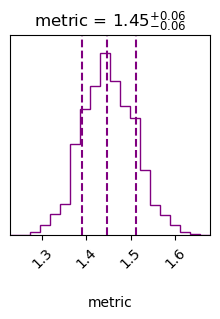

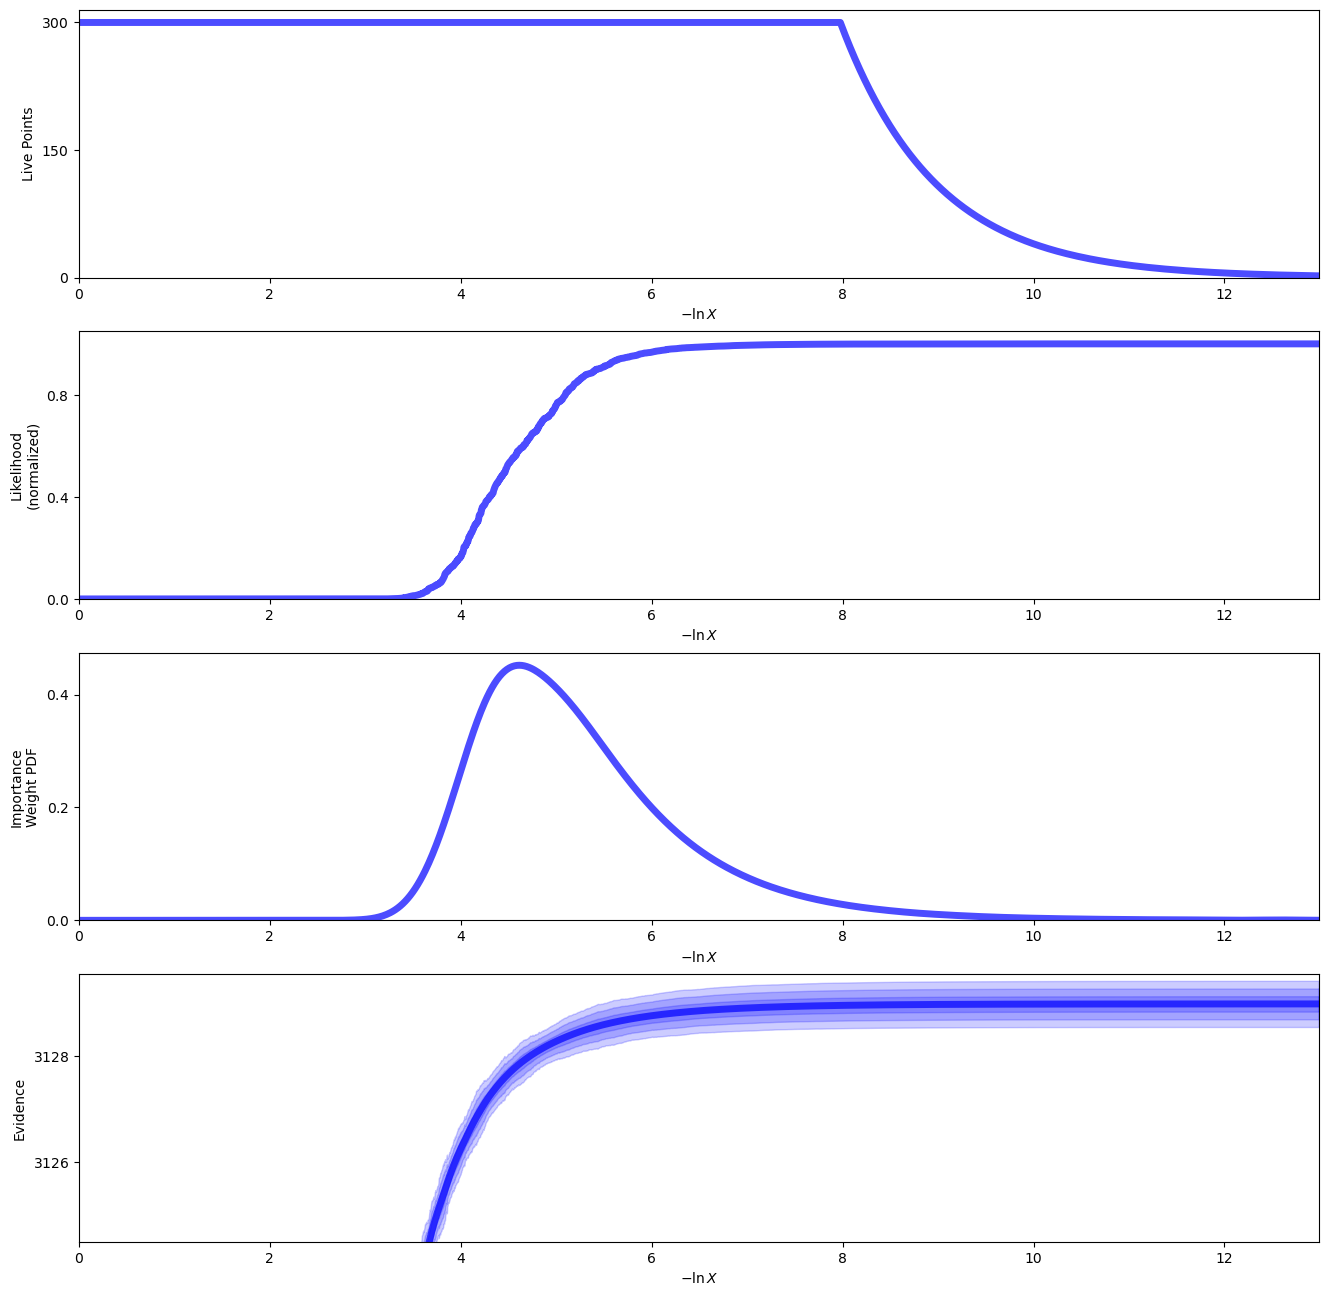

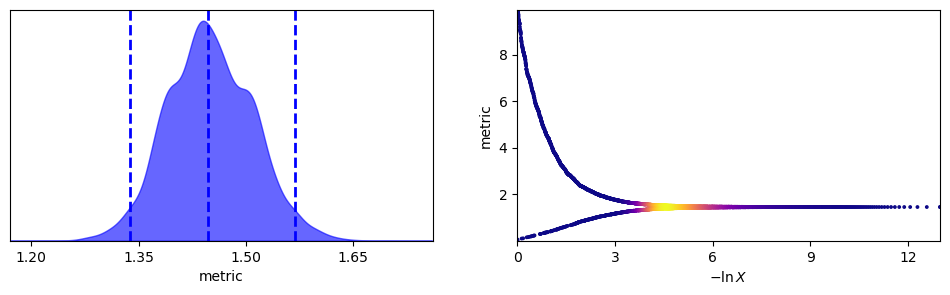

In [8]:
sampler_GP_water.plot()

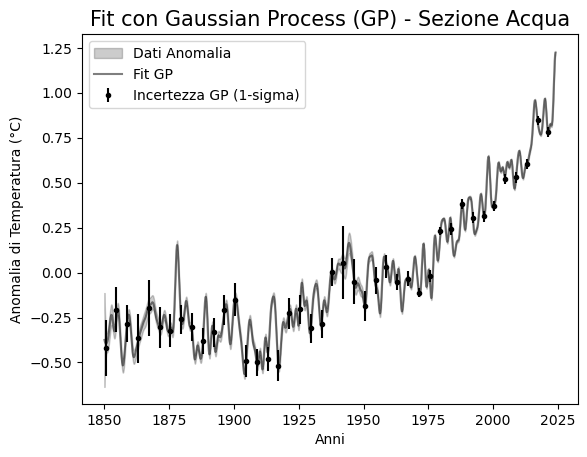

In [9]:
mean_metric_water = results_GP_water['samples'].mean()
time_train = data_water_masked['time_centered']
anomalies_water = data_water_masked['Annual_Anomaly']
anomalies_unc_water = data_water_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric_water)
res_gp = george.GP(res_kernel)
res_gp.compute(time_train, anomalies_unc_water)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies_water, t_grid_calc, return_var=True)

plt.errorbar(data_water_masked['time_years'][::50], anomalies_water[::50], yerr=anomalies_unc_water[::50], fmt=".k", capsize=0, zorder=0)
plt.fill_between(t_grid_plot, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(t_grid_plot, pred_anomalies, "k", lw=1.5, alpha=0.5)
plt.legend(['Dati Anomalia', 'Fit GP', 'Incertezza GP (1-sigma)'])
plt.xlabel('Anni')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Fit con Gaussian Process (GP) - Sezione Acqua', fontsize=15)
plt.show()

### Processi Gaussiani con Trend

In [106]:
class Exp(Model):
    parameter_names = ("a", "b", "c")
    def get_value(self, t):
        return self.a * np.exp(self.b * (t)) + self.c

def prior_exponential_safe(cube):
    params = cube.copy()
    params[0] = cube[0] * 0.5         # a
    params[1] = cube[1] * 0.5          # b
    params[2] = cube[2] * 3.0 - 0.5     # c
    params[3] = cube[3] * 10.0 - 5.0   # lc
    params[4] = cube[4] * 15.0 - 2.0   

    return params

class Linear(Model):
    parameter_names = ("a", "b")
    def get_value(self, t):
        return self.a * t + self.b

def prior_linear_safe(cube):
    params = cube.copy()
    params[0] = cube[0] * 0.01       # a
    params[1] = cube[1] * 2.0-1.0        # b
    params[2] = cube[2] * 10.0 - 5.0   # lc
    params[3] = cube[3] * 15.0 - 2.0   

    return params

class quadratic(Model):
    parameter_names = ("a", "b", "c")
    def get_value(self, t):
        return self.a * t**2 + self.b * t + self.c
    
def prior_quadratic_safe(cube):
    params = cube.copy()
    params[0] = cube[0] * 0.5
    params[1] = cube[1] * 2.0 - 1.0
    params[2] = cube[2] * 2.0 - 1.0
    params[3] = cube[3] * 10.0 - 5.0
    params[4] = cube[4] * 15.0 - 2.0   

    return params

class constant(Model):
    parameter_names = ("a",)
    def get_value(self, t):
        return self.a * np.ones(len(t))
    
def prior_constant_safe(cube):
    params = cube.copy()
    params[0] = cube[0] * 10.0 - 5.0
    params[1] = cube[1] * 10.0 - 5.0
    params[2] = cube[2] * 15.0 - 2.0   

    return params

In [107]:
print("Inizializzazione Kernel e Dati...")
kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
exp_model = george.GP(kernel=kernel, mean=Exp(a=0.0, b=0.00, c=0.0))

def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(y_data, quiet=True)

t_data = data_air_masked['time_centered'][::12]
y_data = data_air_masked['Annual_Anomaly'][::12]
u_data = data_air_masked['Annual_Anomaly_Unc'][::12]

exp_model.compute(t_data, u_data)

param_names = ['a', 'b', 'c', 'lc', 'log_metric']

print("Preparazione Sampler...")
sampler = ReactiveNestedSampler(
    param_names, 
    log_likelihood, 
    prior_exponential_safe,
)

print("Tutto pronto. INIZIO CAMPIONAMENTO!")
results = sampler.run(min_num_live_points=300)

sampler.print_results()

Inizializzazione Kernel e Dati...
Preparazione Sampler...
Tutto pronto. INIZIO CAMPIONAMENTO!
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=1e+02  4 [131.7806..131.7808]*| it/evals=7821/132966 eff=5.8953% N=300   0 0   
[ultranest] Likelihood function evaluations: 132985
[ultranest]   logZ = 110.4 +- 0.1454
[ultranest] Effective samples strategy satisfied (ESS = 1779.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

logZ = 110.396 +- 0.331
  single instance: logZ = 110.396 +- 0.252
  bootstrapped   : logZ = 110.357 +- 0.331
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0058│ ▁▁▁▁▃▄▆▇▇▇▇▆▅▄▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁  ▁ │0.0949    0.0323 +- 0.0099
    b                   : 0.0151│ ▁ ▁▁▁▁▁▁▁▁▂▂▄▅▅▆▆▇▇▇▇▅▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │0.0298    0.0225 +- 0.0018
    c                   

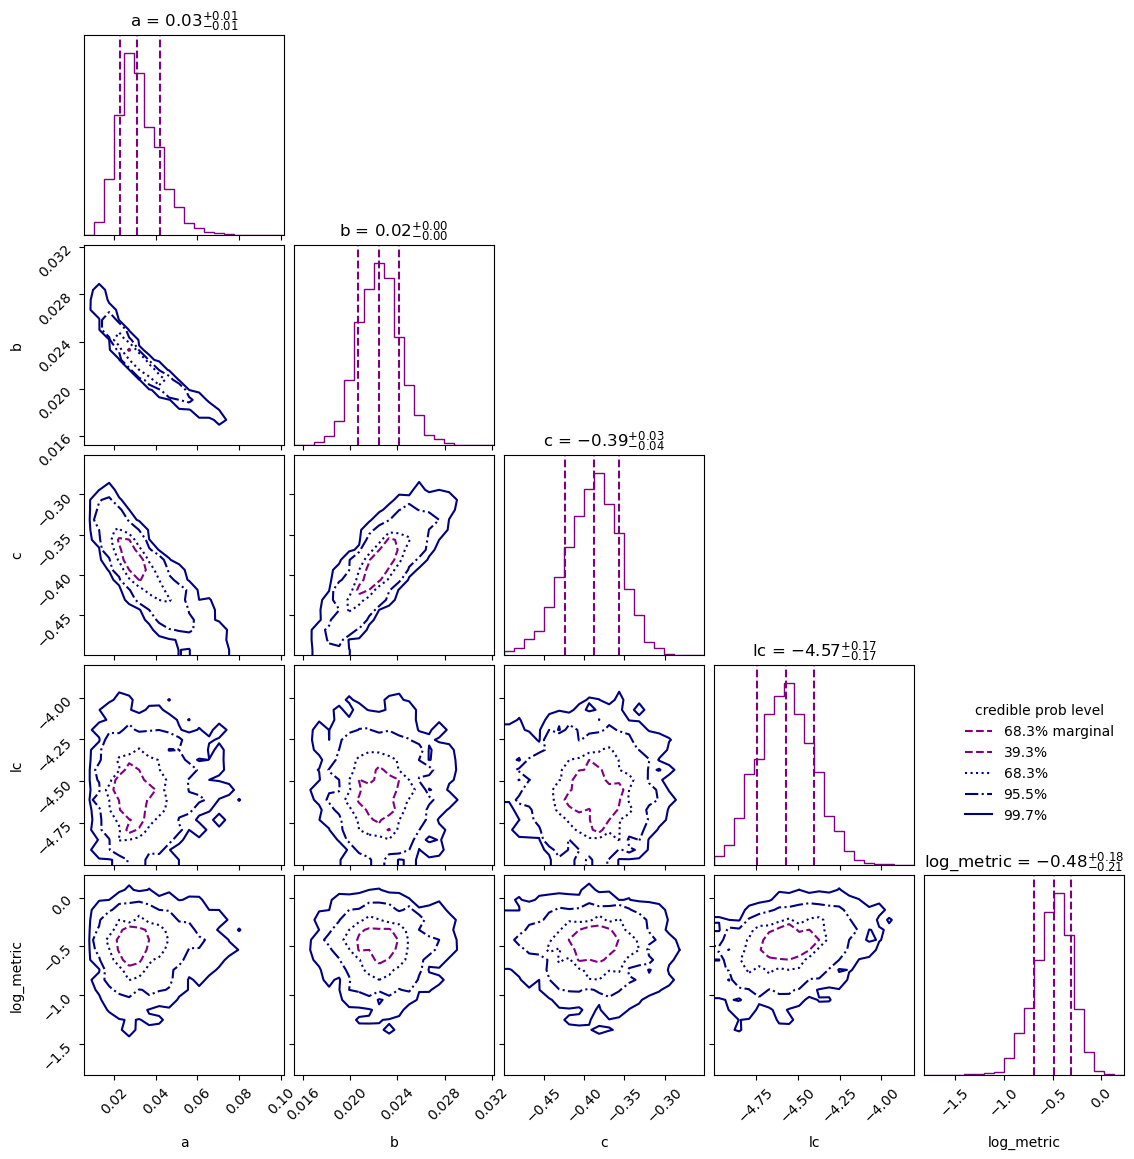

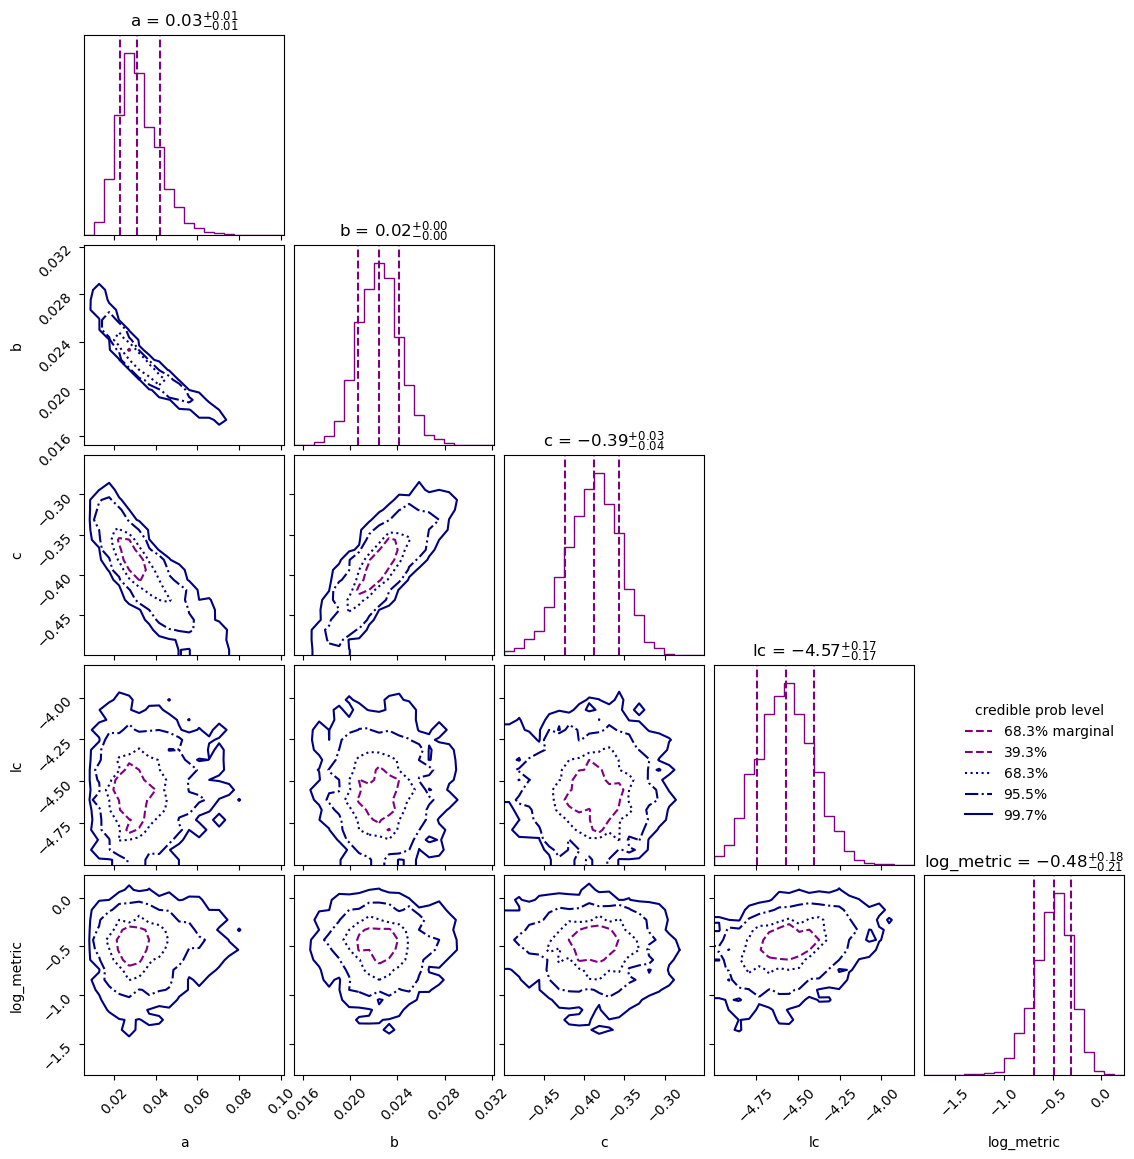

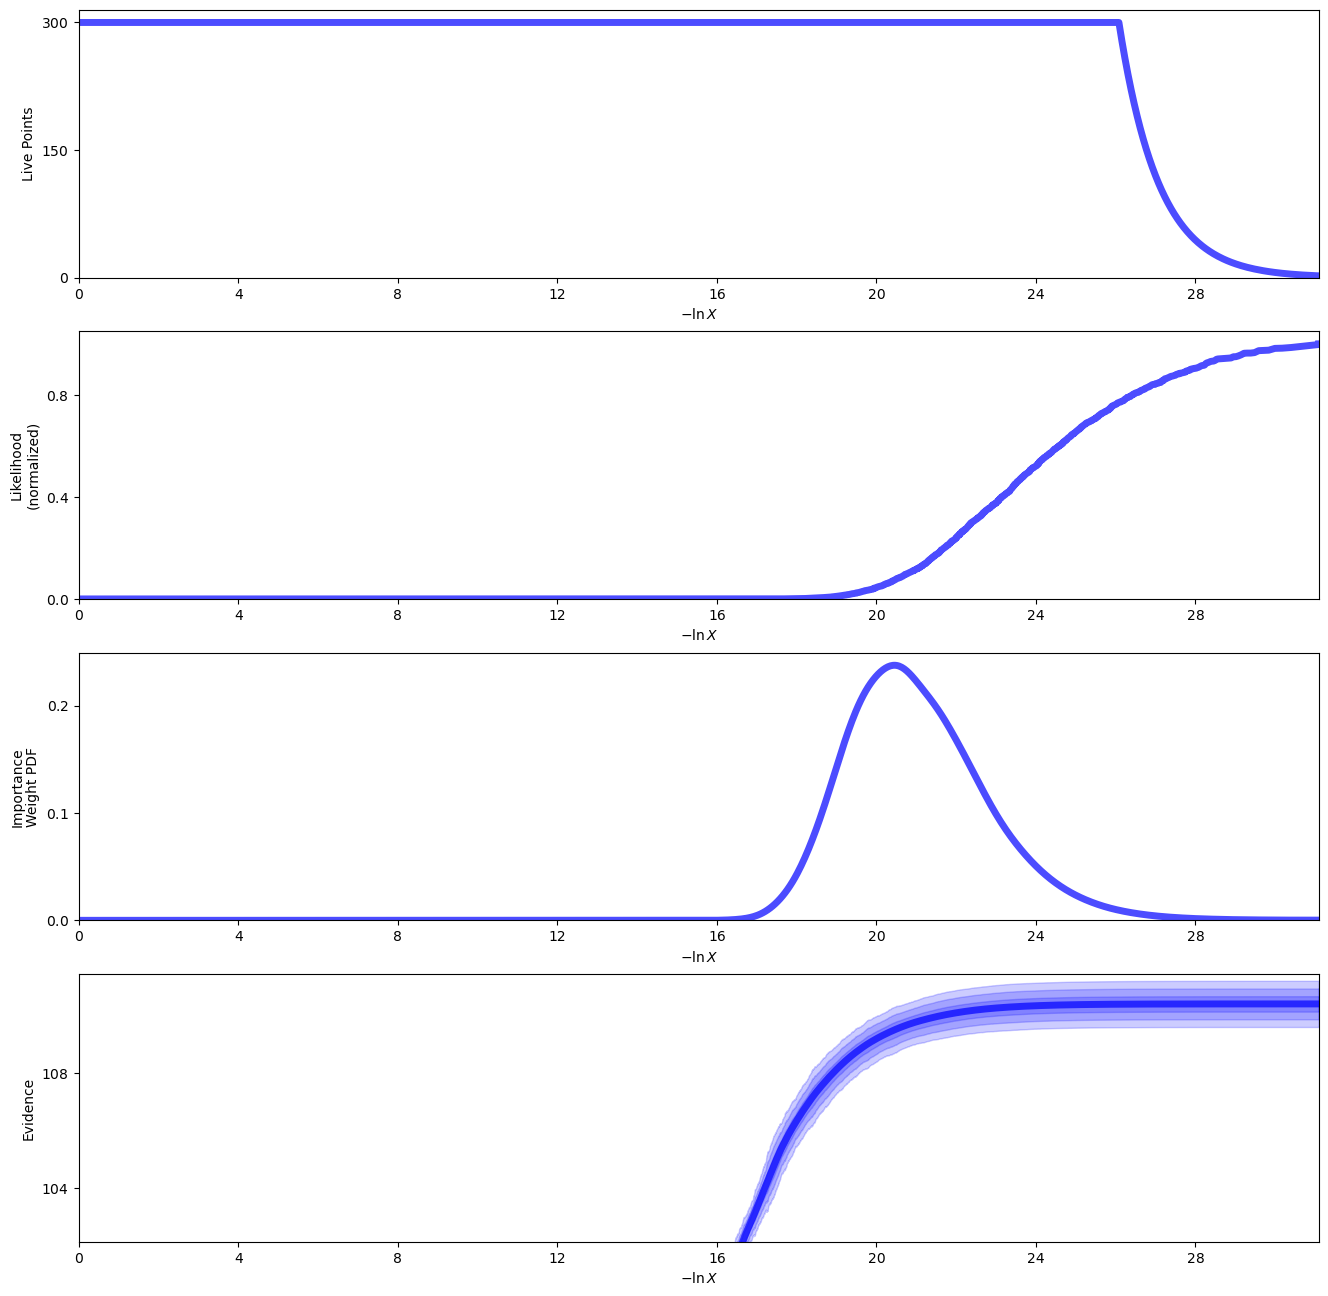

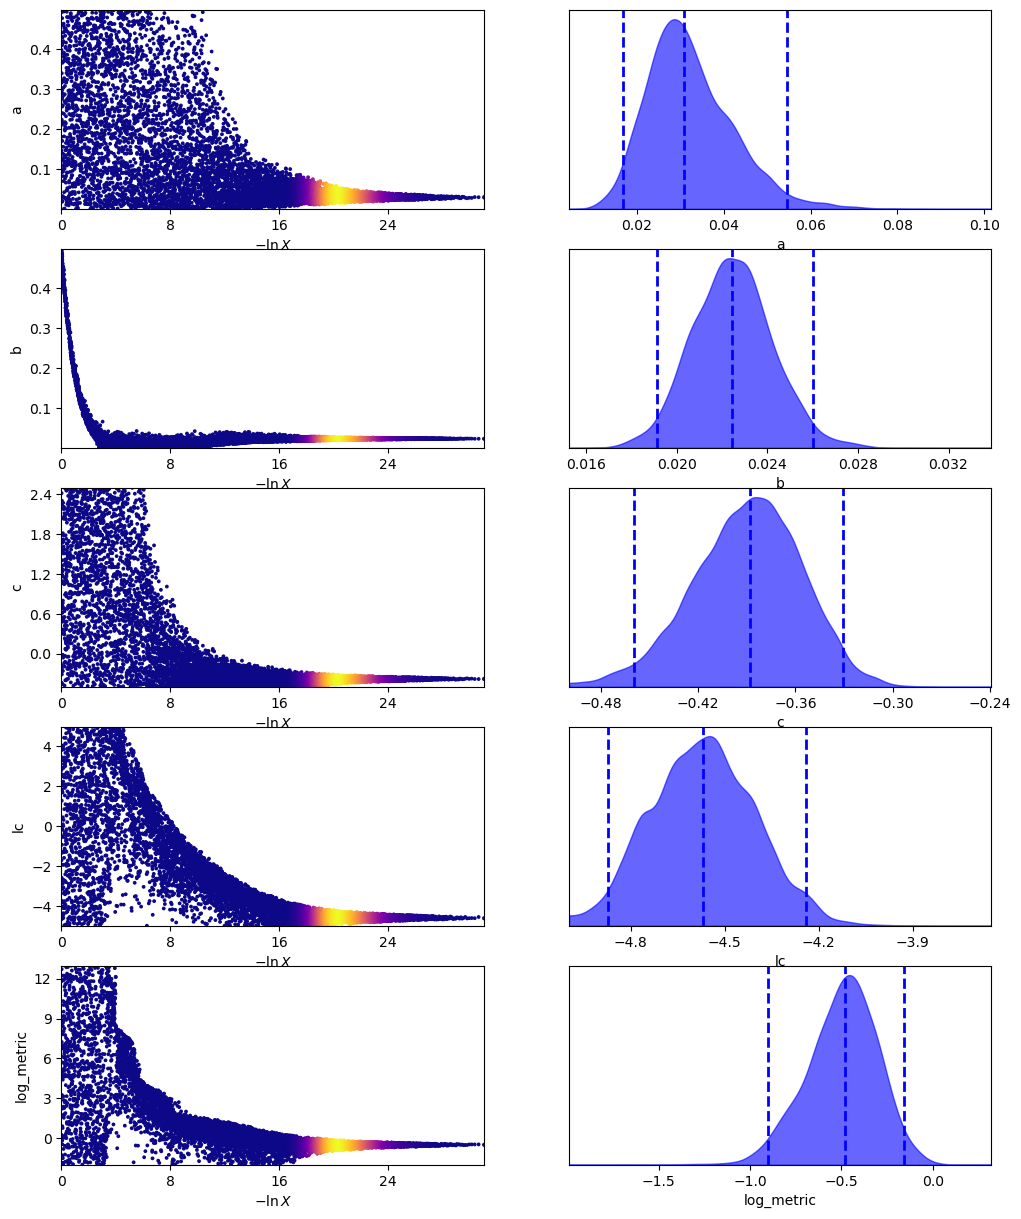

In [ ]:
cornerplot(results);

Parametri migliori utilizzati per la predizione:
[np.float64(0.030853115885706592), np.float64(0.022432389133293748), np.float64(-0.38816442635088055), np.float64(-4.570205296464888), np.float64(-0.4840639270630832)]


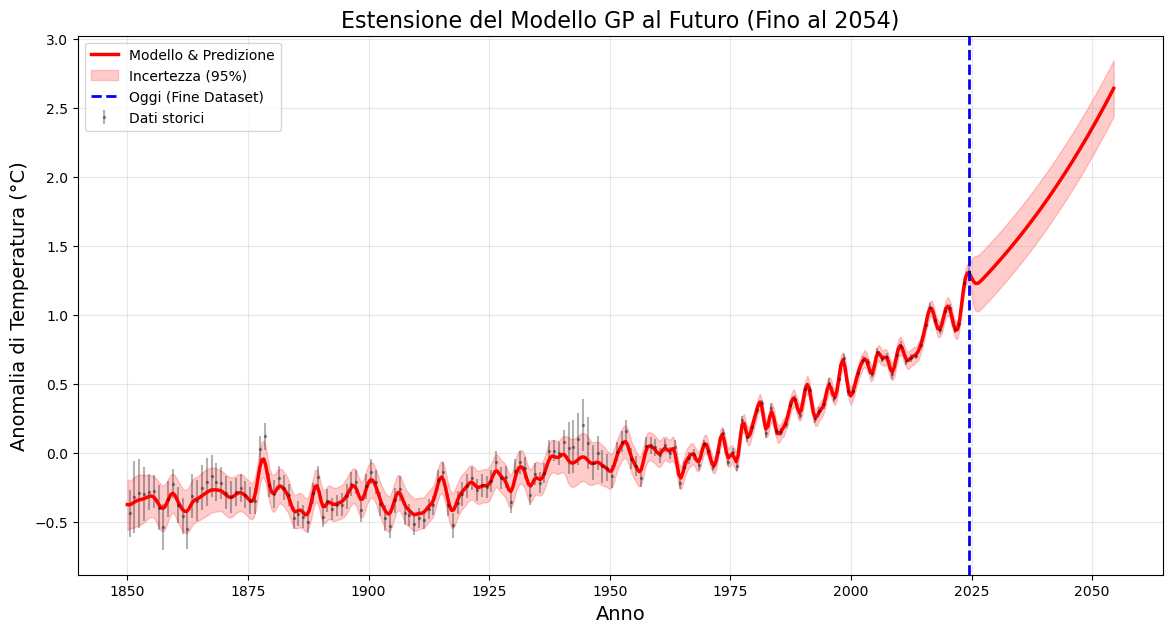

In [109]:
import matplotlib.pyplot as plt

# 1. Estrai i parametri "migliori" (la mediana della distribuzione trovata da UltraNest)
best_params = [np.median(results['samples'][:, i]) for i in range(len(param_names))]
print(f"Parametri migliori utilizzati per la predizione:\n{best_params}")

# 2. Aggiorna il modello di George con questi parametri
exp_model.set_parameter_vector(best_params)

# 3. Crea l'asse del tempo futuro (es. andiamo avanti di 30 anni)
t_ultimo_dato = t_data.max()
anni_futuri = 30
t_pred = np.linspace(0, t_ultimo_dato + anni_futuri, 500)

# Convertiamo in anni solari per il grafico (assumendo che t=0 sia il 1850)
t_pred_years = t_pred + 1850 

# 4. Calcola la predizione!
# Passiamo i dati vecchi (y_data), i tempi nuovi (t_pred) e chiediamo la varianza
mu_pred, var_pred = exp_model.predict(y_data, t_pred, return_var=True)

# Calcoliamo la deviazione standard (sigma) per l'incertezza
std_pred = np.sqrt(var_pred)

# 5. Plottiamo i Dati, il Fit e il Futuro
plt.figure(figsize=(14, 7))

# Plot dei dati storici
plt.errorbar(t_data + 1850, y_data, yerr=u_data, fmt='.k', markersize=3, alpha=0.3, label='Dati storici')

# Plot della predizione futura (Linea centrale)
plt.plot(t_pred_years, mu_pred, color='red', lw=2.5, label='Modello & Predizione')

# Plot della fascia di incertezza (2-sigma, confidenza ~95%)
plt.fill_between(t_pred_years, mu_pred - 2*std_pred, mu_pred + 2*std_pred, 
                 color='red', alpha=0.2, label='Incertezza (95%)')

# Mettiamo una riga verticale per separare il passato dal futuro
plt.axvline(t_ultimo_dato + 1850, color='blue', linestyle='--', lw=2, label='Oggi (Fine Dataset)')

plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.title('Estensione del Modello GP al Futuro (Fino al 2054)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

### Modello lineare

In [ ]:
print("Inizializzazione Kernel e Dati...")
kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
linear_model = george.GP(kernel=kernel, mean=Linear(a=0.0, b=0.0))

def log_likelihood_linear(params):
    linear_model.set_parameter_vector(params)
    return linear_model.log_likelihood(y_data, quiet=True)

t_data = data_air_masked['time_centered'][::12]
y_data = data_air_masked['Annual_Anomaly'][::12]
u_data = data_air_masked['Annual_Anomaly_Unc'][::12]

linear_model.compute(t_data, u_data)

param_names_linear = ['a', 'b', 'lc', 'log_metric']

print("Preparazione Sampler...")
sampler_linear = ReactiveNestedSampler(
    param_names_linear, 
    log_likelihood_linear, 
    prior_linear_safe,
)


print("Tutto pronto. INIZIO CAMPIONAMENTO!")
results_linear= sampler_linear.run(min_num_live_points=300)

sampler_linear.print_results()

Inizializzazione Kernel e Dati...
Preparazione Sampler...
Tutto pronto. INIZIO CAMPIONAMENTO!
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=8e+01  80.5703..80.5709]*| it/evals=5201/14190 eff=37.4442% N=300       
[ultranest] Likelihood function evaluations: 14201
[ultranest]   logZ = 67.9 +- 0.1579
[ultranest] Effective samples strategy satisfied (ESS = 1668.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.19 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

logZ = 67.877 +- 0.344
  single instance: logZ = 67.877 +- 0.189
  bootstrapped   : logZ = 67.897 +- 0.344
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00534│ ▁▁▁▁▁▁▁▁▁▂▃▄▄▅▆▇▇▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁▁ ▁ │0.00941    0.00730 +- 0.00050
    b                   : -0.868│ ▁  ▁▁▁▁▁▁▁▁▃▃▄▅▆▆▇▆▇▅▅▅▃▃▂▁▁▁▁▁▁▁▁▁ ▁ │-0.387    -0.630 +- 0.052
    lc                  : -3.97 │

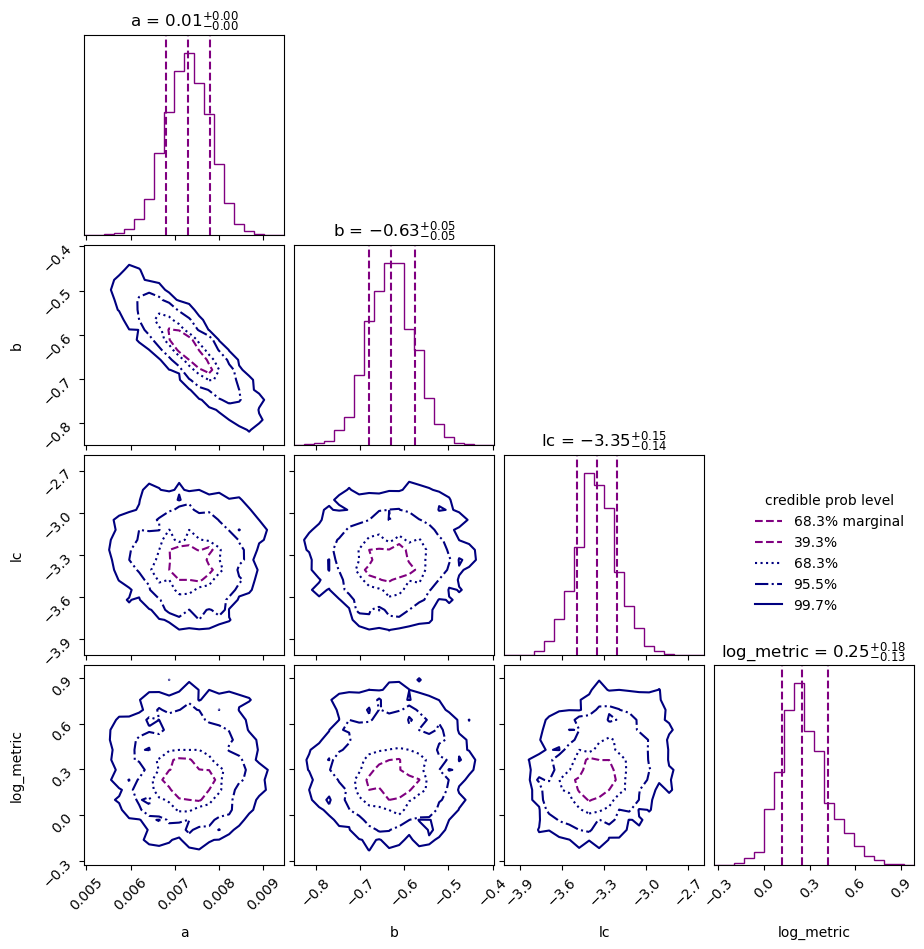

In [72]:
cornerplot(results_linear);

Parametri migliori utilizzati per la predizione:
[np.float64(0.007294500692460817), np.float64(-0.6305887011123241), np.float64(-3.354223576911645), np.float64(0.2487232041072711)]


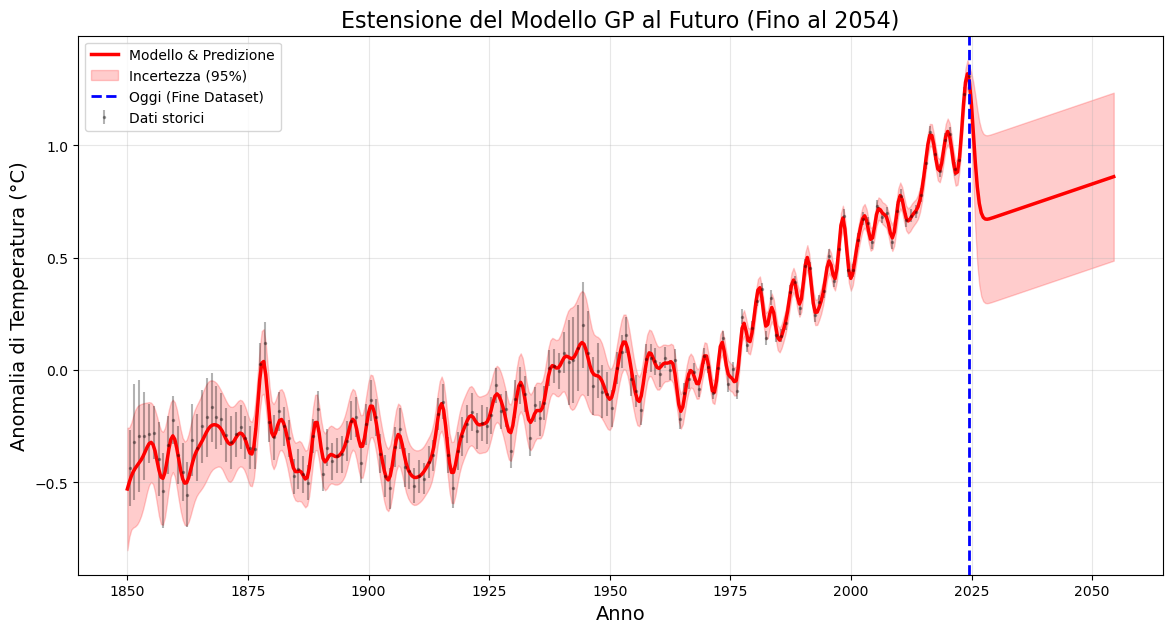

In [96]:
import matplotlib.pyplot as plt

# 1. Estrai i parametri "migliori" (la mediana della distribuzione trovata da UltraNest)
best_params_linear = [np.median(results_linear['samples'][:, i]) for i in range(len(param_names_linear))]
print(f"Parametri migliori utilizzati per la predizione:\n{best_params_linear}")

# 2. Aggiorna il modello di George con questi parametri
linear_model.set_parameter_vector(best_params_linear)

# 3. Crea l'asse del tempo futuro (es. andiamo avanti di 30 anni)
t_ultimo_dato = t_data.max()
anni_futuri = 30
t_pred = np.linspace(0, t_ultimo_dato + anni_futuri, 500)

# Convertiamo in anni solari per il grafico (assumendo che t=0 sia il 1850)
t_pred_years = t_pred + 1850 

# 4. Calcola la predizione!
# Passiamo i dati vecchi (y_data), i tempi nuovi (t_pred) e chiediamo la varianza
mu_pred, var_pred = linear_model.predict(y_data, t_pred, return_var=True)

# Calcoliamo la deviazione standard (sigma) per l'incertezza
std_pred = np.sqrt(var_pred)

# 5. Plottiamo i Dati, il Fit e il Futuro
plt.figure(figsize=(14, 7))

# Plot dei dati storici
plt.errorbar(t_data + 1850, y_data, yerr=u_data, fmt='.k', markersize=3, alpha=0.3, label='Dati storici')

# Plot della predizione futura (Linea centrale)
plt.plot(t_pred_years, mu_pred, color='red', lw=2.5, label='Modello & Predizione')

# Plot della fascia di incertezza (2-sigma, confidenza ~95%)
plt.fill_between(t_pred_years, mu_pred - 2*std_pred, mu_pred + 2*std_pred, 
                 color='red', alpha=0.2, label='Incertezza (95%)')

# Mettiamo una riga verticale per separare il passato dal futuro
plt.axvline(t_ultimo_dato + 1850, color='blue', linestyle='--', lw=2, label='Oggi (Fine Dataset)')

plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.title('Estensione del Modello GP al Futuro (Fino al 2054)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

### Modello quadratico

In [ ]:
print("Inizializzazione Kernel e Dati...")
kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
quadratic_model = george.GP(kernel=kernel, mean=quadratic(a=0.0, b=0.0, c=0.0))

def log_likelihood_quadratic(params):
    quadratic_model.set_parameter_vector(params)
    return quadratic_model.log_likelihood(y_data, quiet=True)

t_data = data_air_masked['time_centered'][::12]
y_data = data_air_masked['Annual_Anomaly'][::12]
u_data = data_air_masked['Annual_Anomaly_Unc'][::12]

quadratic_model.compute(t_data, u_data)

param_names_quadratic = ['a', 'b', 'c', 'lc', 'log_metric']

print("Preparazione Sampler...")
sampler_quadratic = ReactiveNestedSampler(
    param_names_quadratic, 
    log_likelihood_quadratic, 
    prior_quadratic_safe,
)

print("Tutto pronto. INIZIO CAMPIONAMENTO!")
results_quadratic= sampler_quadratic.run(min_num_live_points=300)

sampler_quadratic.print_results()

Inizializzazione Kernel e Dati...
Preparazione Sampler...
Tutto pronto. INIZIO CAMPIONAMENTO!
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=1e+02   [124.9669..124.9670]*| it/evals=10117/64190 eff=15.8350% N=300    0        0  0    
[ultranest] Likelihood function evaluations: 64202
[ultranest]   logZ = 95.85 +- 0.1911
[ultranest] Effective samples strategy satisfied (ESS = 1720.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.15 to 0.56, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.

logZ = 95.910 +- 0.405
  single instance: logZ = 95.910 +- 0.300
  bootstrapped   : logZ = 95.852 +- 0.404
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0000535│ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▆▇▇▇▆▅▄▂▃▂▁▁▁▁▁▁ ▁ ▁ │0.0001072    0.0000801 +- 0.0000060
    b                   : -0.0117│ ▁ ▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▆▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │

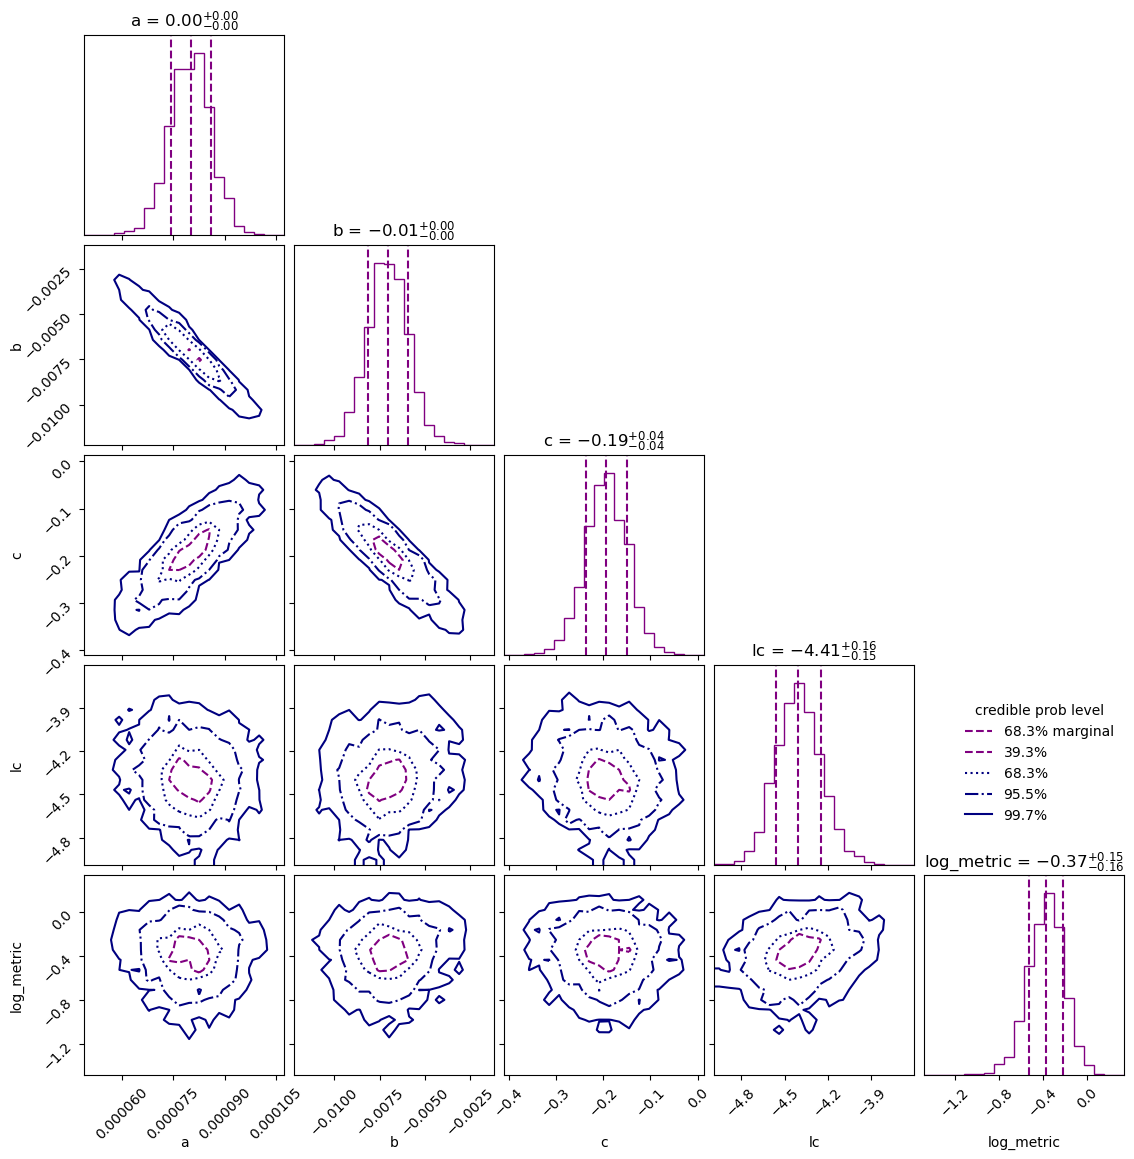

In [74]:
cornerplot(results_quadratic);

Parametri migliori utilizzati per la predizione:
[np.float64(8.011326108145372e-05), np.float64(-0.007061504978944755), np.float64(-0.19336443925770253), np.float64(-4.406443459603084), np.float64(-0.3704264006307374)]


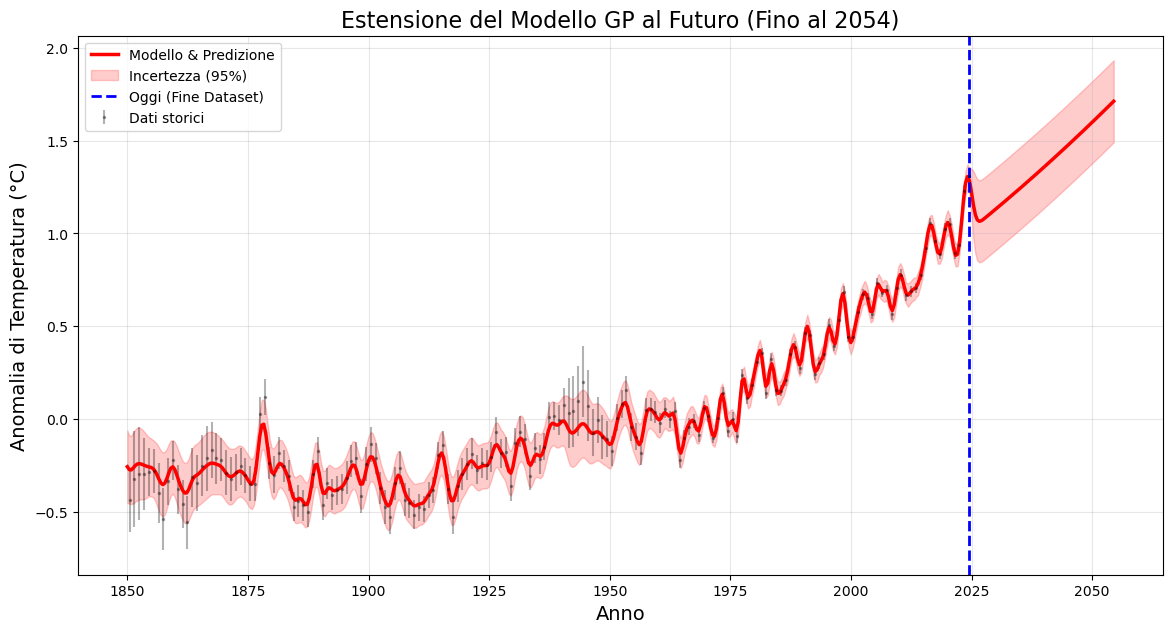

In [97]:
import matplotlib.pyplot as plt

# 1. Estrai i parametri "migliori" (la mediana della distribuzione trovata da UltraNest)
best_params_quadratic = [np.median(results_quadratic['samples'][:, i]) for i in range(len(param_names_quadratic))]
print(f"Parametri migliori utilizzati per la predizione:\n{best_params_quadratic}")

# 2. Aggiorna il modello di George con questi parametri
quadratic_model.set_parameter_vector(best_params_quadratic)

# 3. Crea l'asse del tempo futuro (es. andiamo avanti di 30 anni)
t_ultimo_dato = t_data.max()
anni_futuri = 30
t_pred = np.linspace(0, t_ultimo_dato + anni_futuri, 500)

# Convertiamo in anni solari per il grafico (assumendo che t=0 sia il 1850)
t_pred_years = t_pred + 1850 

# 4. Calcola la predizione!
# Passiamo i dati vecchi (y_data), i tempi nuovi (t_pred) e chiediamo la varianza
mu_pred, var_pred = quadratic_model.predict(y_data, t_pred, return_var=True)

# Calcoliamo la deviazione standard (sigma) per l'incertezza
std_pred = np.sqrt(var_pred)

# 5. Plottiamo i Dati, il Fit e il Futuro
plt.figure(figsize=(14, 7))

# Plot dei dati storici
plt.errorbar(t_data + 1850, y_data, yerr=u_data, fmt='.k', markersize=3, alpha=0.3, label='Dati storici')

# Plot della predizione futura (Linea centrale)
plt.plot(t_pred_years, mu_pred, color='red', lw=2.5, label='Modello & Predizione')

# Plot della fascia di incertezza (2-sigma, confidenza ~95%)
plt.fill_between(t_pred_years, mu_pred - 2*std_pred, mu_pred + 2*std_pred, 
                 color='red', alpha=0.2, label='Incertezza (95%)')

# Mettiamo una riga verticale per separare il passato dal futuro
plt.axvline(t_ultimo_dato + 1850, color='blue', linestyle='--', lw=2, label='Oggi (Fine Dataset)')

plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.title('Estensione del Modello GP al Futuro (Fino al 2054)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

### Modello costante

In [100]:
print("Inizializzazione Kernel e Dati...")
kernel = kernels.ConstantKernel(log_constant=1.0) * kernels.ExpSquaredKernel(1.0)
constant_model = george.GP(kernel=kernel, mean=constant(a=0.0))

def log_likelihood(params):
    constant_model.set_parameter_vector(params)
    return constant_model.log_likelihood(y_data, quiet=True)

t_data = data_air_masked['time_centered'][::12]
y_data = data_air_masked['Annual_Anomaly'][::12]
u_data = data_air_masked['Annual_Anomaly_Unc'][::12]

constant_model.compute(t_data, u_data)

param_names_constant = ['a', 'lc', 'log_metric']

print("Preparazione Sampler...")
sampler_constant = ReactiveNestedSampler(
    param_names_constant, 
    log_likelihood, 
    prior_constant_safe,
)

print("Tutto pronto. INIZIO CAMPIONAMENTO!")
results_constant = sampler_constant.run(min_num_live_points=300)

sampler_constant.print_results()

Inizializzazione Kernel e Dati...
Preparazione Sampler...
Tutto pronto. INIZIO CAMPIONAMENTO!
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=3e+01  34.0117..34.0119]*| it/evals=4931/11916 eff=42.4501% N=300        
[ultranest] Likelihood function evaluations: 11920
[ultranest]   logZ = 22.13 +- 0.1225
[ultranest] Effective samples strategy satisfied (ESS = 1469.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.19 bs:0.12 tail:0.01 total:0.12 required:<0.50
[ultranest] done iterating.

logZ = 22.194 +- 0.149
  single instance: logZ = 22.194 +- 0.185
  bootstrapped   : logZ = 22.130 +- 0.148
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : -0.202│ ▁▁▁▁▁▁▁▂▂▃▃▅▆▆▇▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁    ▁ │0.310     0.018 +- 0.057
    lc                  : -2.75 │ ▁▁ ▁▁▁▁▁▁▂▂▄▄▅▆▆▇▇▆▅▆▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁ │-1.32     -2.08 +- 0.17
    log_metric          : 0.597 │ ▁▁▁▁▁

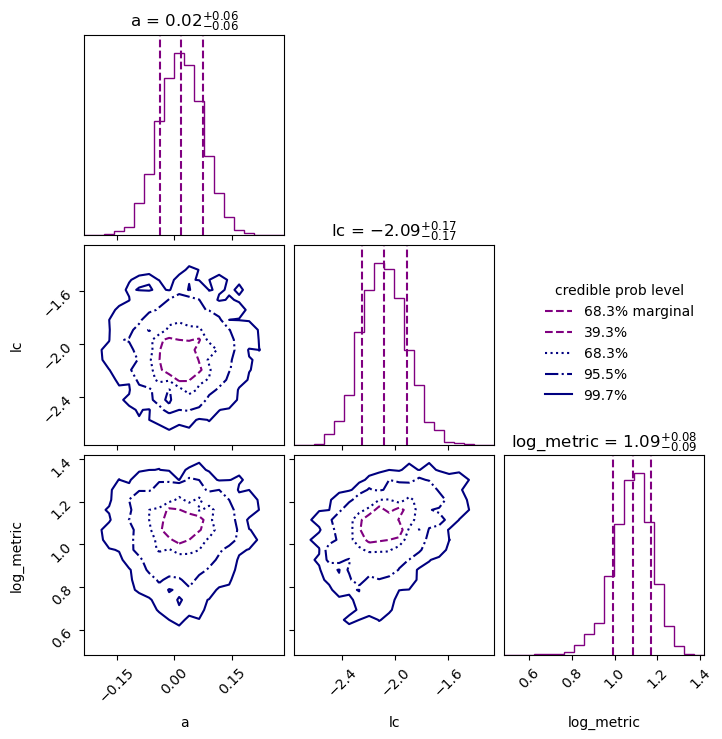

In [101]:
cornerplot(results_constant);

Parametri migliori utilizzati per la predizione:
[np.float64(0.017093949994916535), np.float64(-2.0858962410200146), np.float64(1.0874427295277038)]


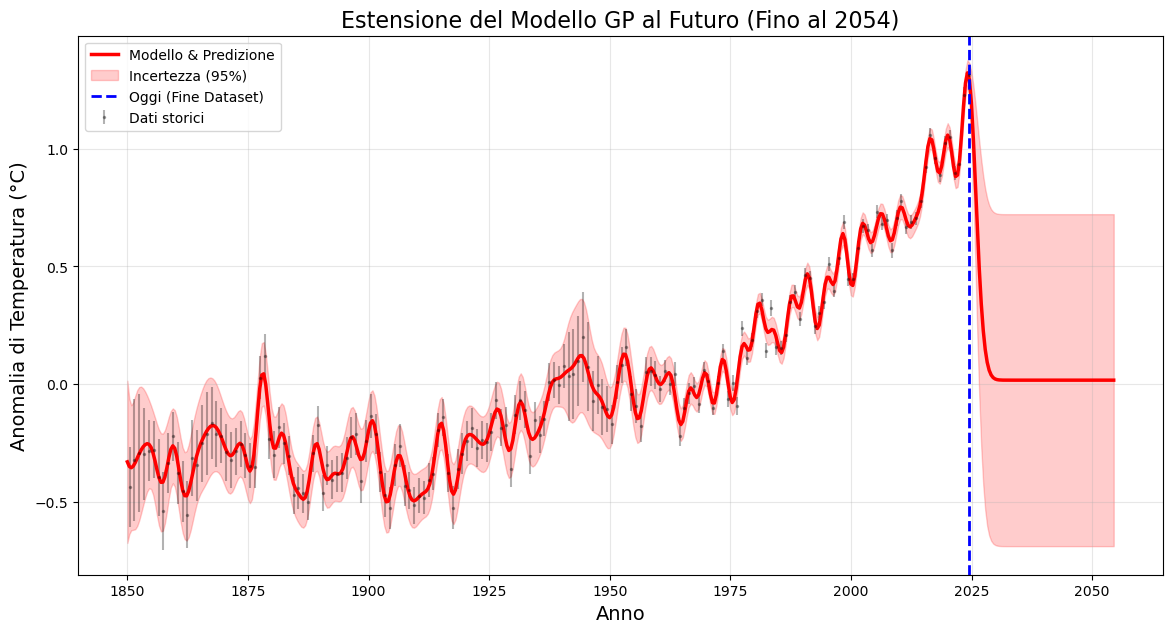

In [102]:
import matplotlib.pyplot as plt

# 1. Estrai i parametri "migliori" (la mediana della distribuzione trovata da UltraNest)
best_params_const = [np.median(results_constant['samples'][:, i]) for i in range(len(param_names_constant))]
print(f"Parametri migliori utilizzati per la predizione:\n{best_params_const}")

# 2. Aggiorna il modello di George con questi parametri
constant_model.set_parameter_vector(best_params_const)

# 3. Crea l'asse del tempo futuro (es. andiamo avanti di 30 anni)
t_ultimo_dato = t_data.max()
anni_futuri = 30
t_pred = np.linspace(0, t_ultimo_dato + anni_futuri, 500)

# Convertiamo in anni solari per il grafico (assumendo che t=0 sia il 1850)
t_pred_years = t_pred + 1850 

# 4. Calcola la predizione!
# Passiamo i dati vecchi (y_data), i tempi nuovi (t_pred) e chiediamo la varianza
mu_pred, var_pred = constant_model.predict(y_data, t_pred, return_var=True)

# Calcoliamo la deviazione standard (sigma) per l'incertezza
std_pred = np.sqrt(var_pred)

# 5. Plottiamo i Dati, il Fit e il Futuro
plt.figure(figsize=(14, 7))

# Plot dei dati storici
plt.errorbar(t_data + 1850, y_data, yerr=u_data, fmt='.k', markersize=3, alpha=0.3, label='Dati storici')

# Plot della predizione futura (Linea centrale)
plt.plot(t_pred_years, mu_pred, color='red', lw=2.5, label='Modello & Predizione')

# Plot della fascia di incertezza (2-sigma, confidenza ~95%)
plt.fill_between(t_pred_years, mu_pred - 2*std_pred, mu_pred + 2*std_pred, 
                 color='red', alpha=0.2, label='Incertezza (95%)')

# Mettiamo una riga verticale per separare il passato dal futuro
plt.axvline(t_ultimo_dato + 1850, color='blue', linestyle='--', lw=2, label='Oggi (Fine Dataset)')

plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.title('Estensione del Modello GP al Futuro (Fino al 2054)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

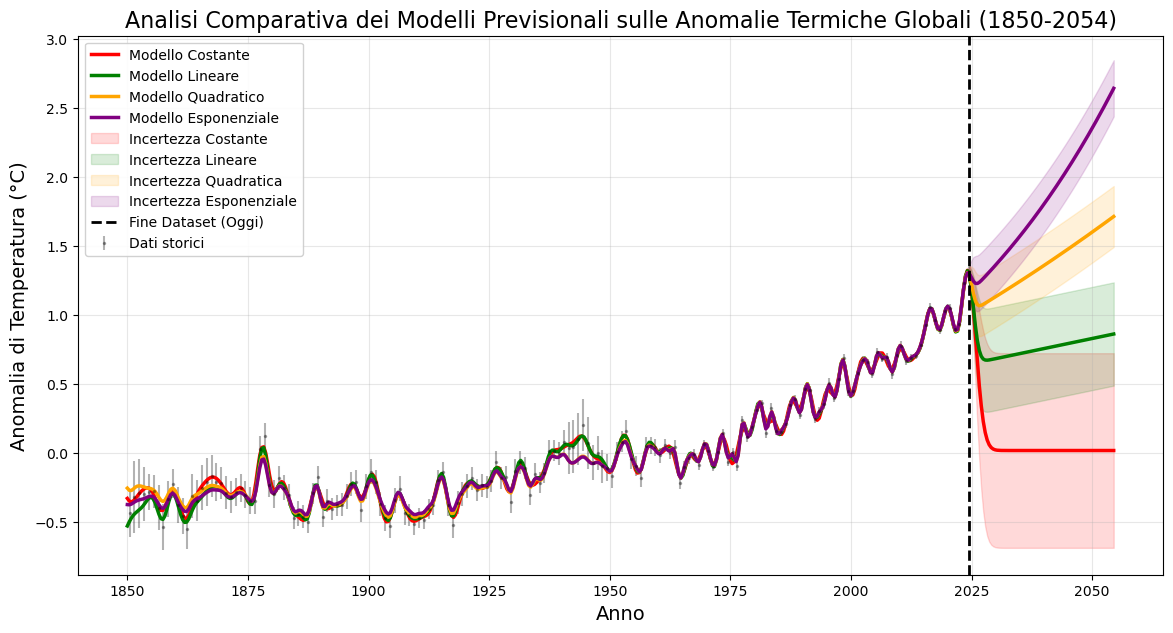

In [114]:

mu_pred_const, var_pred_const = constant_model.predict(y_data, t_pred, return_var=True)
mu_pred_linear, var_pred_linear = linear_model.predict(y_data, t_pred, return_var=True)
mu_pred_quadratic, var_pred_quadratic = quadratic_model.predict(y_data, t_pred, return_var=True)
mu_pred_exp, var_pred_exp = exp_model.predict(y_data, t_pred, return_var=True)

# Calcoliamo la deviazione standard (sigma) per l'incertezza
std_pred_const = np.sqrt(var_pred_const)
std_pred_linear = np.sqrt(var_pred_linear)
std_pred_quadratic = np.sqrt(var_pred_quadratic)
std_pred_exp = np.sqrt(var_pred_exp)

# 5. Plottiamo i Dati, il Fit e il Futuro
plt.figure(figsize=(14, 7))

# Plot dei dati storici
plt.errorbar(t_data + 1850, y_data, yerr=u_data, fmt='.k', markersize=3, alpha=0.3, label='Dati storici')

# Plot della predizione (Linea centrale su tutto il periodo)
plt.plot(t_pred_years, mu_pred_const, color='red', lw=2.5, label='Modello Costante')
plt.plot(t_pred_years, mu_pred_linear, color='green', lw=2.5, label='Modello Lineare')
plt.plot(t_pred_years, mu_pred_quadratic, color='orange', lw=2.5, label='Modello Quadratico')
plt.plot(t_pred_years, mu_pred_exp, color='purple', lw=2.5, label='Modello Esponenziale')

# Creiamo una condizione logica: "Vero" solo per gli anni successivi all'ultimo dato
solo_futuro = t_pred_years >= (t_ultimo_dato + 1850)

# Plot della fascia di incertezza (SOLO NEL FUTURO grazie a where=solo_futuro)
plt.fill_between(t_pred_years, mu_pred_const - 2*std_pred_const, mu_pred_const + 2*std_pred_const, 
                 where=solo_futuro, color='red', alpha=0.15, label='Incertezza Costante')

plt.fill_between(t_pred_years, mu_pred_linear - 2*std_pred_linear, mu_pred_linear + 2*std_pred_linear, 
                 where=solo_futuro, color='green', alpha=0.15, label='Incertezza Lineare')

plt.fill_between(t_pred_years, mu_pred_quadratic - 2*std_pred_quadratic, mu_pred_quadratic + 2*std_pred_quadratic, 
                 where=solo_futuro, color='orange', alpha=0.15, label='Incertezza Quadratica')

plt.fill_between(t_pred_years, mu_pred_exp - 2*std_pred_exp, mu_pred_exp + 2*std_pred_exp, 
                 where=solo_futuro, color='purple', alpha=0.15, label='Incertezza Esponenziale')

# Mettiamo una riga verticale per separare il passato dal futuro
plt.axvline(t_ultimo_dato + 1850, color='black', linestyle='--', lw=2, zorder=5, label='Fine Dataset (Oggi)')

plt.xlabel('Anno', fontsize=14)
plt.ylabel('Anomalia di Temperatura (°C)', fontsize=14)
plt.title('Analisi Comparativa dei Modelli Previsionali sulle Anomalie Termiche Globali (1850-2054)', fontsize=16)

# Posizioniamo la legenda fuori se diventa troppo ingombrante, o la lasciamo in alto a sinistra
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(alpha=0.3)

plt.show()